# AusLAMP Victorian MT Data: Time Series QA/QC

**Goal**: Load and analyze time series data from all sites to assess data quality, identify orientation issues, detect bad data, and visualize time series characteristics.

**Data**: EDL MiniSEED files from E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_raw

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from edl_reader import read_edl_station, get_all_stations_metadata

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Pandas display options - show all rows and use regular notation
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.float_format', '{:.2f}'.format)  # No scientific notation

def caption(text):
    """Display a figure caption as wrapped, italic markdown."""
    display(Markdown(f"*{text}*"))

## 1. Statistical Review of All Sites

Load a representative sample from each site and calculate statistics to identify:
- Orientation issues (mean field values significantly different from expected)
- Bad data (excessive outliers, unrealistic values)
- Data quality metrics

In [2]:
# Base directory containing all stations
base_dir = Path(r'E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_raw')

# Get metadata for all stations first
print("Loading metadata for all stations...")
metadata_df = get_all_stations_metadata(base_dir, station_pattern='VIC*')

print(f"\nFound {len(metadata_df)} stations")
print(f"First 10: {metadata_df['station_id'].head(10).tolist()}")

Loading metadata for all stations...
Reading metadata: VIC001...
Reading metadata: VIC002...
Reading metadata: VIC003...
Reading metadata: VIC005...
Reading metadata: VIC006...
Reading metadata: VIC007...
Reading metadata: VIC008...
Reading metadata: VIC010...
Reading metadata: VIC011...
Reading metadata: VIC013...
Reading metadata: VIC014...
Reading metadata: VIC015...
Reading metadata: VIC017...
Reading metadata: VIC018...
Reading metadata: VIC022...
Reading metadata: VIC023...
Reading metadata: VIC024...
Reading metadata: VIC026...
Reading metadata: VIC027...
Reading metadata: VIC028...
Reading metadata: VIC030...
Reading metadata: VIC031...
Reading metadata: VIC032...
Reading metadata: VIC036...
Reading metadata: VIC037...
Reading metadata: VIC038...
Reading metadata: VIC039...
Reading metadata: VIC040...
Reading metadata: VIC041...
Reading metadata: VIC042...
Reading metadata: VIC043...
Reading metadata: VIC045...
Reading metadata: VIC046...
Reading metadata: VIC047...
Reading met

In [3]:
# Load ALL data from each site for statistical analysis
import time

site_stats = []

station_dirs = sorted([d for d in base_dir.glob('VIC*') if d.is_dir()])

# Output directory for daily ASCII files
output_base = Path(r'E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_2026')
output_base.mkdir(exist_ok=True)

print(f"Processing {len(station_dirs)} stations...\n")
print(f"Exporting daily ASCII files to: {output_base}\n")

for i, station_dir in enumerate(station_dirs):
    station_id = station_dir.name
    start_time = time.time()
    
    print(f"[{i+1}/{len(station_dirs)}] Loading {station_id}...", end='', flush=True)
    
    try:
        # Load ALL data from this site
        df = read_edl_station(station_dir, channels='all', verbose=False)
        
        elapsed = time.time() - start_time
        print(f" {len(df):,} samples, {(df.index[-1] - df.index[0]).total_seconds()/86400:.1f} days ({elapsed:.1f}s)", end='')
        
        # Export to daily ASCII files
        station_output_dir = output_base / station_id
        station_output_dir.mkdir(exist_ok=True)
        
        # Group by day
        df['date'] = df.index.date
        days = df.groupby('date')
        
        n_days_exported = 0
        for date, day_df in days:
            # Get start time of this day's data
            day_start = day_df.index[0]
            
            # Format: YYYYMMDDHHMMSS.dat
            filename = day_start.strftime('%Y%m%d%H%M%S') + '.dat'
            filepath = station_output_dir / filename
            
            # Select time series channels only (BX, BY, BZ, EX, EY)
            # Drop the date column we added
            export_df = day_df[['BX', 'BY', 'BZ', 'EX', 'EY']].copy()
            
            # Save as ASCII with space-separated values
            # Include timestamp as first column
            export_df.insert(0, 'DateTime', export_df.index.strftime('%Y-%m-%d %H:%M:%S.%f'))
            
            # Write to file
            export_df.to_csv(filepath, sep=' ', index=False, float_format='%.6f')
            n_days_exported += 1
        
        print(f" → exported {n_days_exported} day files", end='')
        
        # Remove temporary date column
        df = df.drop('date', axis=1)
        
        # Calculate statistics on ALL data
        stats = {
            'station_id': station_id,
            'n_samples': len(df),
            'duration_days': (df.index[-1] - df.index[0]).total_seconds() / 86400,
            
            # Magnetic field means
            'bx_mean': df['BX'].mean(),
            'by_mean': df['BY'].mean(),
            'bz_mean': df['BZ'].mean(),
            
            # Magnetic field standard deviations
            'bx_std': df['BX'].std(),
            'by_std': df['BY'].std(),
            'bz_std': df['BZ'].std(),
            
            # Electric field means
            'ex_mean': df['EX'].mean(),
            'ey_mean': df['EY'].mean(),
            
            # Electric field standard deviations
            'ex_std': df['EX'].std(),
            'ey_std': df['EY'].std(),
            
            # Temperature
            'tp_mean': df['TP'].mean(),
            'tp_std': df['TP'].std(),
            
            # Horizontal and total field
            'h_mean': np.sqrt(df['BX']**2 + df['BY']**2).mean(),
            'f_mean': np.sqrt(df['BX']**2 + df['BY']**2 + df['BZ']**2).mean(),
            
            # Outlier counts (>5σ) - use full dataset
            'bx_outliers': (np.abs(df['BX'] - df['BX'].mean()) > 5*df['BX'].std()).sum(),
            'by_outliers': (np.abs(df['BY'] - df['BY'].mean()) > 5*df['BY'].std()).sum(),
            'bz_outliers': (np.abs(df['BZ'] - df['BZ'].mean()) > 5*df['BZ'].std()).sum(),
        }
        
        site_stats.append(stats)
        print()  # New line after each site
        
    except Exception as e:
        print(f" ERROR: {e}")
        continue

print(f"\n{'='*60}")
print(f"Done! Successfully loaded {len(site_stats)} sites")
print(f"Daily ASCII files saved to: {output_base}")

# Convert to DataFrame
stats_df = pd.DataFrame(site_stats)

Processing 81 stations...

Exporting daily ASCII files to: E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_2026

[1/81] Loading VIC001... 23,148,000 samples, 26.8 days (114.4s) → exported 28 day files
[2/81] Loading VIC002... 20,880,000 samples, 24.2 days (97.1s) → exported 25 day files
[3/81] Loading VIC003... 22,320,000 samples, 25.8 days (76.7s) → exported 26 day files
[4/81] Loading VIC005... 15,516,000 samples, 18.0 days (64.1s) → exported 18 day files
[5/81] Loading VIC006... 28,188,000 samples, 32.6 days (153.2s) → exported 33 day files
[6/81] Loading VIC007... 15,912,000 samples, 18.4 days (65.8s) → exported 19 day files
[7/81] Loading VIC008... 24,912,000 samples, 28.8 days (128.5s) → exported 29 day files
[8/81] Loading VIC010... 22,356,000 samples, 25.9 days (109.2s) → exported 27 day files
[9/81] Loading VIC011... 19,512,000 samples, 22.6 days (90.7s) → exported 23 day files
[10/81] Loading VIC013... 21,615,600 samples, 25.0 days (104.4s) → exported 26 day files
[11/81] Loading VIC

In [5]:
# Merge statistics with metadata
combined_df = pd.merge(metadata_df, stats_df, on='station_id', how='inner', suffixes=('_meta', '_stats'))

# Check which columns we actually have
print("Available columns:", combined_df.columns.tolist())

# Use duration_days from stats (more accurate since it's from actual loaded data)
# Drop the metadata version if it exists
if 'duration_days_meta' in combined_df.columns and 'duration_days_stats' in combined_df.columns:
    combined_df = combined_df.drop('duration_days_meta', axis=1)
    combined_df = combined_df.rename(columns={'duration_days_stats': 'duration_days'})

# Also handle n_samples if duplicated
if 'n_samples_meta' in combined_df.columns and 'n_samples_stats' in combined_df.columns:
    combined_df = combined_df.drop('n_samples_meta', axis=1)
    combined_df = combined_df.rename(columns={'n_samples_stats': 'n_samples'})

# Reorder columns for better readability
column_order = [
    'station_id', 'latitude', 'longitude', 'elevation',
    'start_time', 'end_time', 'duration_days', 'n_days', 'n_files', 'n_samples',
    'bx_mean', 'by_mean', 'bz_mean', 'h_mean', 'f_mean',
    'bx_std', 'by_std', 'bz_std',
    'ex_mean', 'ey_mean', 'ex_std', 'ey_std',
    'tp_mean', 'tp_std',
    'bx_outliers', 'by_outliers', 'bz_outliers'
]

# Only select columns that exist
available_columns = [col for col in column_order if col in combined_df.columns]
combined_df = combined_df[available_columns]

print(f"\nCombined metadata and statistics for {len(combined_df)} sites")

Available columns: ['station_id', 'latitude', 'longitude', 'elevation', 'start_time', 'end_time', 'n_days', 'n_files', 'duration_days_meta', 'n_samples', 'duration_days_stats', 'bx_mean', 'by_mean', 'bz_mean', 'bx_std', 'by_std', 'bz_std', 'ex_mean', 'ey_mean', 'ex_std', 'ey_std', 'tp_mean', 'tp_std', 'h_mean', 'f_mean', 'bx_outliers', 'by_outliers', 'bz_outliers']

Combined metadata and statistics for 71 sites


### Display Full Statistics Table

All sites shown below (scrollable if needed):

In [6]:
# Display full table
combined_df

,station_id,latitude,longitude,elevation,start_time,end_time,duration_days,n_days,n_files,n_samples,...,bz_std,ex_mean,ey_mean,ex_std,ey_std,tp_mean,tp_std,bx_outliers,by_outliers,bz_outliers
0,VIC001,-38.92,146.44,94.00,2014-04-11 06:00:00,2014-05-08 00:27:18.400,26.79,28,1929,23148000,...,141.53,78214.23,140982.80,132267.28,172229.54,17869.63,29919.71,95,89,225166
1,VIC002,-38.34,142.47,36.00,2014-05-13 00:00:00,2014-06-06 03:27:18.400,24.17,25,1740,20880000,...,9.13,-303407.27,-311448.49,117682.13,81027.56,-18632.48,10679.99,512,21260,60438
2,VIC003,-38.52,142.97,146.00,2014-05-12 03:00:00,2014-06-06 22:43:14.100,25.83,26,1884,22320000,...,214.50,-421118.54,145764.19,77659.00,51385.44,-43505.63,13041.19,327,350,320
3,VIC005,-38.51,143.99,178.00,2014-05-11 00:00:00,2014-05-28 22:29:34.900,17.96,18,1293,15516000,...,23.56,214174.31,-97813.45,24761.33,218798.21,53883.07,22802.73,0,4288,740
4,VIC006,-38.45,145.00,124.00,2014-04-06 07:00:00,2014-05-08 21:27:18.400,32.62,33,2349,28188000,...,22.24,-94620.52,143916.54,160477.00,76414.10,56516.08,15347.51,0,0,0
5,VIC007,-38.50,145.51,44.00,2014-05-08 08:00:00,2014-05-26 17:27:18.400,18.42,19,1326,15912000,...,9.10,224746.06,-206503.16,50647.83,104472.64,-59490.06,13379.30,14689,12776,79
6,VIC008,-38.50,146.00,123.00,2014-04-09 02:00:00,2014-05-07 21:38:41.000,28.83,29,2076,24912000,...,9.06,55116.03,335239.20,159796.57,131230.73,25336.20,25639.92,0,478685,128089
7,VIC010,-38.47,147.03,8.00,2014-04-11 05:00:00,2014-05-07 01:27:18.400,25.87,27,1863,22356000,...,15.43,61397.03,71210.21,28923.99,15724.15,-569007.68,2561.15,12588,278,209
8,VIC011,-38.03,141.03,40.00,2014-05-18 07:00:00,2014-06-09 21:27:18.400,22.58,23,1629,19512000,...,10.57,-426957.38,5635.49,199463.20,32202.82,-11603.91,19162.42,0,484,11811
9,VIC013,-38.00,142.02,149.00,2014-05-16 04:00:00,2014-06-10 04:25:01.800,25.02,26,1803,21615600,...,14.82,253265.96,-243067.51,46561.54,47820.98,18607.51,7951.40,29701,6596,43452


In [7]:
# Summary statistics across all sites
print("Summary Statistics Across All Sites:\n")
display(combined_df[['bx_mean', 'by_mean', 'bz_mean', 'h_mean', 'f_mean']].describe())

Summary Statistics Across All Sites:



,bx_mean,by_mean,bz_mean,h_mean,f_mean
count,71.00,71.00,71.00,71.00,71.00
mean,20226.84,729.26,-52462.55,21980.62,57673.02
std,7985.16,4103.70,9039.88,3497.90,5225.89
min,-23404.71,-22493.33,-56874.46,2760.51,24889.32
25%,20593.44,-751.35,-55134.58,21361.90,58488.99
50%,21903.74,1354.51,-54516.10,22318.60,58922.95
75%,23001.61,3220.76,-53535.10,23540.46,59442.19
max,26751.17,6850.44,9226.17,30707.20,64634.71


### Save Combined Data to CSV

In [8]:
# Note: CSV export moved to after quality flags are calculated (see cell after quality flagging)

### Identify Potential Issues

Look for sites with unusual characteristics:
- Mean field values far from regional average (orientation issues)
- Excessive outliers (>1% of data)
- Unusually high standard deviations (noisy data)

In [9]:
# Calculate regional medians
regional_bx = combined_df['bx_mean'].median()
regional_by = combined_df['by_mean'].median()
regional_bz = combined_df['bz_mean'].median()

print(f"Regional median field values:")
print(f"  Bx: {regional_bx:.2f} nT")
print(f"  By: {regional_by:.2f} nT")
print(f"  Bz: {regional_bz:.2f} nT")

# Flag sites with significant deviations (>1000 nT from median)
threshold = 1000

combined_df['bx_anomaly'] = np.abs(combined_df['bx_mean'] - regional_bx) > threshold
combined_df['by_anomaly'] = np.abs(combined_df['by_mean'] - regional_by) > threshold
combined_df['bz_anomaly'] = np.abs(combined_df['bz_mean'] - regional_bz) > threshold

# Flag sites with excessive outliers (>1% of samples in 1 hour = >360 outliers)
combined_df['excessive_outliers'] = ((combined_df['bx_outliers'] + combined_df['by_outliers'] + combined_df['bz_outliers']) > 360)

# Flag sites with high noise (std > 50 nT)
combined_df['high_noise'] = (combined_df['bx_std'] > 50) | (combined_df['by_std'] > 50) | (combined_df['bz_std'] > 50)

# Combined flag
combined_df['has_issues'] = combined_df['bx_anomaly'] | combined_df['by_anomaly'] | combined_df['bz_anomaly'] | combined_df['excessive_outliers'] | combined_df['high_noise']

print(f"\nSites with potential issues: {combined_df['has_issues'].sum()}")

Regional median field values:
  Bx: 21903.74 nT
  By: 1354.51 nT
  Bz: -54516.10 nT

Sites with potential issues: 68


In [10]:
# Show problematic sites
if combined_df['has_issues'].sum() > 0:
    print("Sites with potential issues:\n")
    problem_sites = combined_df[combined_df['has_issues']]
    display(problem_sites[['station_id', 'bx_mean', 'by_mean', 'bz_mean', 'bx_std', 'by_std', 'bz_std',
                           'bx_outliers', 'by_outliers', 'bz_outliers',
                           'bx_anomaly', 'by_anomaly', 'bz_anomaly', 'excessive_outliers', 'high_noise']])
else:
    print("No sites with obvious quality issues detected!")

Sites with potential issues:



,station_id,bx_mean,by_mean,bz_mean,bx_std,by_std,bz_std,bx_outliers,by_outliers,bz_outliers,bx_anomaly,by_anomaly,bz_anomaly,excessive_outliers,high_noise
0,VIC001,22063.30,-1573.10,-55299.21,19.78,20.80,141.53,95,89,225166,False,True,False,True,True
1,VIC002,20526.29,3387.67,-53194.11,12.28,10.54,9.13,512,21260,60438,True,True,True,True,False
2,VIC003,20960.06,-1020.18,-56507.23,80.44,18.72,214.50,327,350,320,False,True,True,True,True
3,VIC005,22342.55,1930.25,-55723.63,49.54,24.26,23.56,0,4288,740,False,False,True,True,False
4,VIC006,22367.89,2639.17,-55580.68,25.08,99.44,22.24,0,0,0,False,True,True,False,True
5,VIC007,19405.80,-2587.24,-56494.99,12.30,14.34,9.10,14689,12776,79,True,True,True,True,False
6,VIC008,20567.72,1049.81,-56095.32,21.50,44.28,9.06,0,478685,128089,True,False,True,True,False
7,VIC010,-23404.71,-503.24,-55244.18,18.81,22.55,15.43,12588,278,209,True,True,False,True,False
8,VIC011,21903.74,827.23,-55952.03,34.13,13.69,10.57,0,484,11811,False,False,True,True,False
9,VIC013,23018.54,-2028.77,-52563.92,14.67,15.54,14.82,29701,6596,43452,True,True,True,True,False


### Visualize Site Statistics

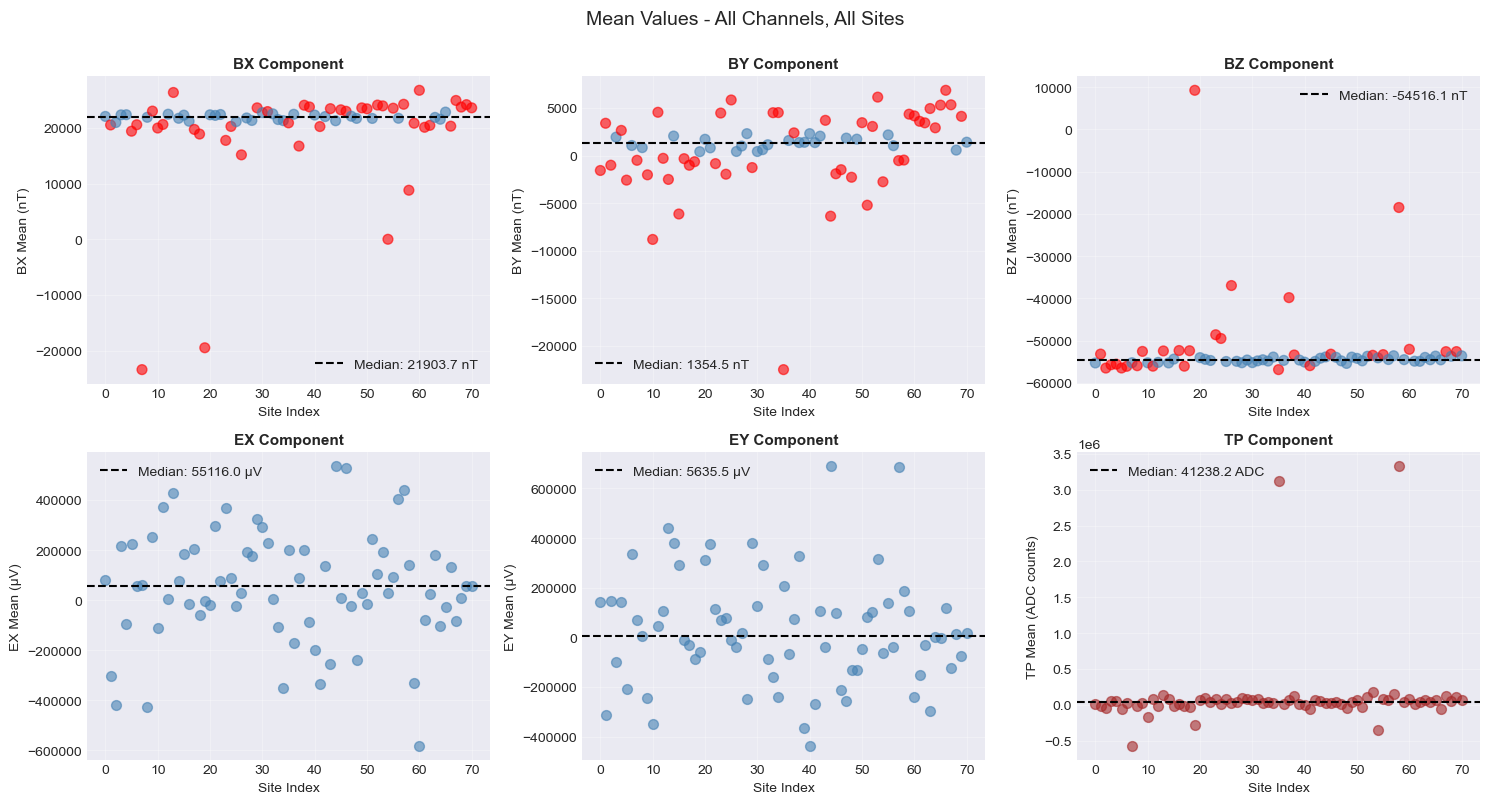

*Figure 1. Mean values for all 6 channels from 71 Victorian AusLAMP sites (full recording duration). **Top row (magnetic)**: Bx varies by 50156 nT, By by 29344 nT, Bz by 66101 nT across the survey area. Red points indicate sites >1000 nT from regional median (potential orientation issues). **Bottom row**: Electric (Ex varies by 1116604 µV, Ey by 1125736 µV) and temperature (varies by 3895339 ADC counts). Electric field baseline variations reflect electrode contact potentials and local geology. Temperature variations reflect different sensor calibrations and recording times. Wide scatter is typical for regional MT surveys spanning different geological provinces. Black dashed lines show regional medians.*

In [11]:
# Plot mean values for ALL channels (magnetic, electric, temperature)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Magnetic channels (top row)
for i, comp in enumerate(['bx', 'by', 'bz']):
    ax = axes[0, i]
    
    # Color by anomaly flag
    colors = combined_df[f'{comp}_anomaly'].map({True: 'red', False: 'steelblue'})
    
    ax.scatter(range(len(combined_df)), combined_df[f'{comp}_mean'], 
              c=colors, alpha=0.6, s=50)
    
    # Add regional median line
    median_val = combined_df[f'{comp}_mean'].median()
    ax.axhline(median_val, color='black', linestyle='--', linewidth=1.5, 
              label=f'Median: {median_val:.1f} nT')
    
    ax.set_ylabel(f'{comp.upper()} Mean (nT)', fontsize=10)
    ax.set_xlabel('Site Index', fontsize=10)
    ax.set_title(f'{comp.upper()} Component', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Electric channels (bottom row, left and center)
for i, comp in enumerate(['ex', 'ey']):
    ax = axes[1, i]
    
    # No anomaly flag for electric - just show all sites
    ax.scatter(range(len(combined_df)), combined_df[f'{comp}_mean'], 
              c='steelblue', alpha=0.6, s=50)
    
    # Add median line
    median_val = combined_df[f'{comp}_mean'].median()
    ax.axhline(median_val, color='black', linestyle='--', linewidth=1.5, 
              label=f'Median: {median_val:.1f} µV')
    
    ax.set_ylabel(f'{comp.upper()} Mean (µV)', fontsize=10)
    ax.set_xlabel('Site Index', fontsize=10)
    ax.set_title(f'{comp.upper()} Component', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Temperature (bottom row, right)
ax = axes[1, 2]
ax.scatter(range(len(combined_df)), combined_df['tp_mean'], 
          c='brown', alpha=0.6, s=50)

# Add median line
median_val = combined_df['tp_mean'].median()
ax.axhline(median_val, color='black', linestyle='--', linewidth=1.5, 
          label=f'Median: {median_val:.1f} ADC')

ax.set_ylabel('TP Mean (ADC counts)', fontsize=10)
ax.set_xlabel('Site Index', fontsize=10)
ax.set_title('TP Component', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Mean Values - All Channels, All Sites', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Calculate statistics for caption
bx_range = combined_df['bx_mean'].max() - combined_df['bx_mean'].min()
by_range = combined_df['by_mean'].max() - combined_df['by_mean'].min()
bz_range = combined_df['bz_mean'].max() - combined_df['bz_mean'].min()
ex_range = combined_df['ex_mean'].max() - combined_df['ex_mean'].min()
ey_range = combined_df['ey_mean'].max() - combined_df['ey_mean'].min()
tp_range = combined_df['tp_mean'].max() - combined_df['tp_mean'].min()

caption(f"Figure 1. Mean values for all 6 channels from {len(combined_df)} Victorian AusLAMP sites (full recording duration). "
        f"**Top row (magnetic)**: Bx varies by {bx_range:.0f} nT, By by {by_range:.0f} nT, Bz by {bz_range:.0f} nT across the survey area. "
        f"Red points indicate sites >1000 nT from regional median (potential orientation issues). "
        f"**Bottom row**: Electric (Ex varies by {ex_range:.0f} µV, Ey by {ey_range:.0f} µV) and temperature (varies by {tp_range:.0f} ADC counts). "
        f"Electric field baseline variations reflect electrode contact potentials and local geology. "
        f"Temperature variations reflect different sensor calibrations and recording times. "
        f"Wide scatter is typical for regional MT surveys spanning different geological provinces. "
        f"Black dashed lines show regional medians.")

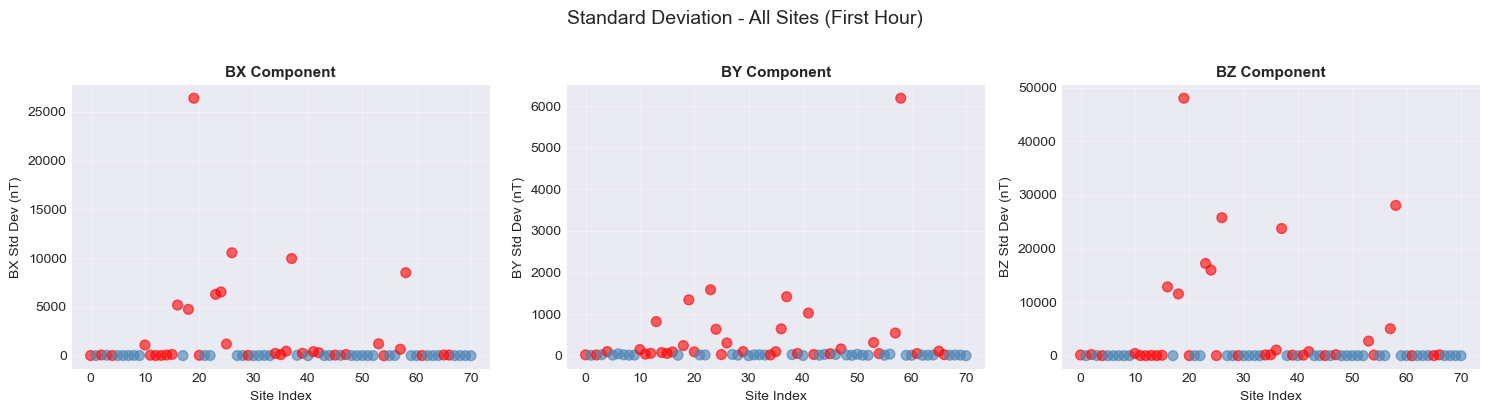

*Figure 2. Standard deviation of magnetic field components for all sites (first hour of data). This measures combined natural field variations and instrument noise. Red points indicate sites with std > 50 nT (potential high noise or instrument problems). Most sites show 10-30 nT std, typical for quiet geomagnetic conditions. Higher values may indicate instrument malfunction or local noise sources.*

In [12]:
# Plot standard deviations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, comp in enumerate(['bx', 'by', 'bz']):
    ax = axes[i]
    
    # Color by high noise flag
    colors = combined_df['high_noise'].map({True: 'red', False: 'steelblue'})
    
    ax.scatter(range(len(combined_df)), combined_df[f'{comp}_std'], 
              c=colors, alpha=0.6, s=50)
    
    ax.set_ylabel(f'{comp.upper()} Std Dev (nT)', fontsize=10)
    ax.set_xlabel('Site Index', fontsize=10)
    ax.set_title(f'{comp.upper()} Component', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Standard Deviation - All Sites (First Hour)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

caption(f"Figure 2. Standard deviation of magnetic field components for all sites (first hour of data). "
        f"This measures combined natural field variations and instrument noise. "
        f"Red points indicate sites with std > 50 nT (potential high noise or instrument problems). "
        f"Most sites show 10-30 nT std, typical for quiet geomagnetic conditions. "
        f"Higher values may indicate instrument malfunction or local noise sources.")

## 2. Detailed Analysis of Representative Site

Select VIC001 for detailed time series analysis.

In [13]:
# Load full dataset for detailed analysis
data_dir = Path(r'E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_raw\VIC001')

print(f"Loading data from: {data_dir.name}")
df = read_edl_station(data_dir, sample_rate=10.0, channels='all', verbose=True)

print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Time range: {df.index[0]} to {df.index[-1]}")
print(f"Duration: {(df.index[-1] - df.index[0]).total_seconds() / 86400:.2f} days")

Loading data from: VIC001
Found 3858 files in VIC001
Time range: 2014-04-11 06:00:00 to 2014-05-08 00:00:00
Loading 643 time segments...
  BX: 36000 samples at 10.0 Hz
  BY: 36000 samples at 10.0 Hz
  BZ: 36000 samples at 10.0 Hz
  EX: 36000 samples at 10.0 Hz
  EY: 36000 samples at 10.0 Hz
  TP: 36000 samples at 10.0 Hz
Loaded 23,148,000 samples at 10.0 Hz
Channels: ['BX', 'BY', 'BZ', 'EX', 'EY', 'TP']

DataFrame shape: (23148000, 6)
Columns: ['BX', 'BY', 'BZ', 'EX', 'EY', 'TP']
Time range: 2014-04-11 06:00:00 to 2014-05-08 00:59:59.900000
Duration: 26.79 days


In [14]:
# Show first few samples
df.head(10)

,BX,BY,BZ,EX,EY,TP
timestamp,,,,,,
2014-04-11 06:00:00.000,22098.13,-1554.07,-53118.14,18932,-100397,1648
2014-04-11 06:00:00.100,22098.13,-1554.06,-53118.07,19004,-100312,1484
2014-04-11 06:00:00.200,22098.12,-1554.06,-53117.80,19070,-100367,1496
2014-04-11 06:00:00.300,22098.12,-1554.06,-53117.93,19172,-100428,1459
2014-04-11 06:00:00.400,22098.14,-1554.04,-53118.14,18694,-100214,1363
2014-04-11 06:00:00.500,22098.14,-1554.05,-53118.57,18951,-100354,1498
2014-04-11 06:00:00.600,22098.13,-1554.06,-53118.73,18749,-100260,1544
2014-04-11 06:00:00.700,22098.15,-1554.05,-53118.85,19003,-100365,1501
2014-04-11 06:00:00.800,22098.13,-1554.07,-53119.10,19058,-100366,1580


In [15]:
# Statistics for all channels
df.describe()

,BX,BY,BZ,EX,EY,TP
count,23148000.00,23148000.00,23148000.00,23148000.00,23148000.00,23148000.00
mean,22063.30,-1573.10,-55299.21,78214.23,140982.80,17869.63
std,19.78,20.80,141.53,132267.28,172229.54,29919.71
min,-2116.62,-1677.00,-55424.62,-449006.00,-297607.00,-116196.00
25%,22053.81,-1586.03,-55321.05,-13991.00,66970.00,3905.00
50%,22065.19,-1577.76,-55313.83,129366.00,174977.00,25576.00
75%,22076.81,-1557.67,-55307.54,176696.00,264990.00,34370.00
max,23863.18,-1000.63,-53023.64,1382142.00,701274.00,444559.00


## 3. Time Series Plots with Automatic Y-Axis Limits

Plot all channels together, with y-axis limits set to mean ± 3σ to handle occasional spikes.

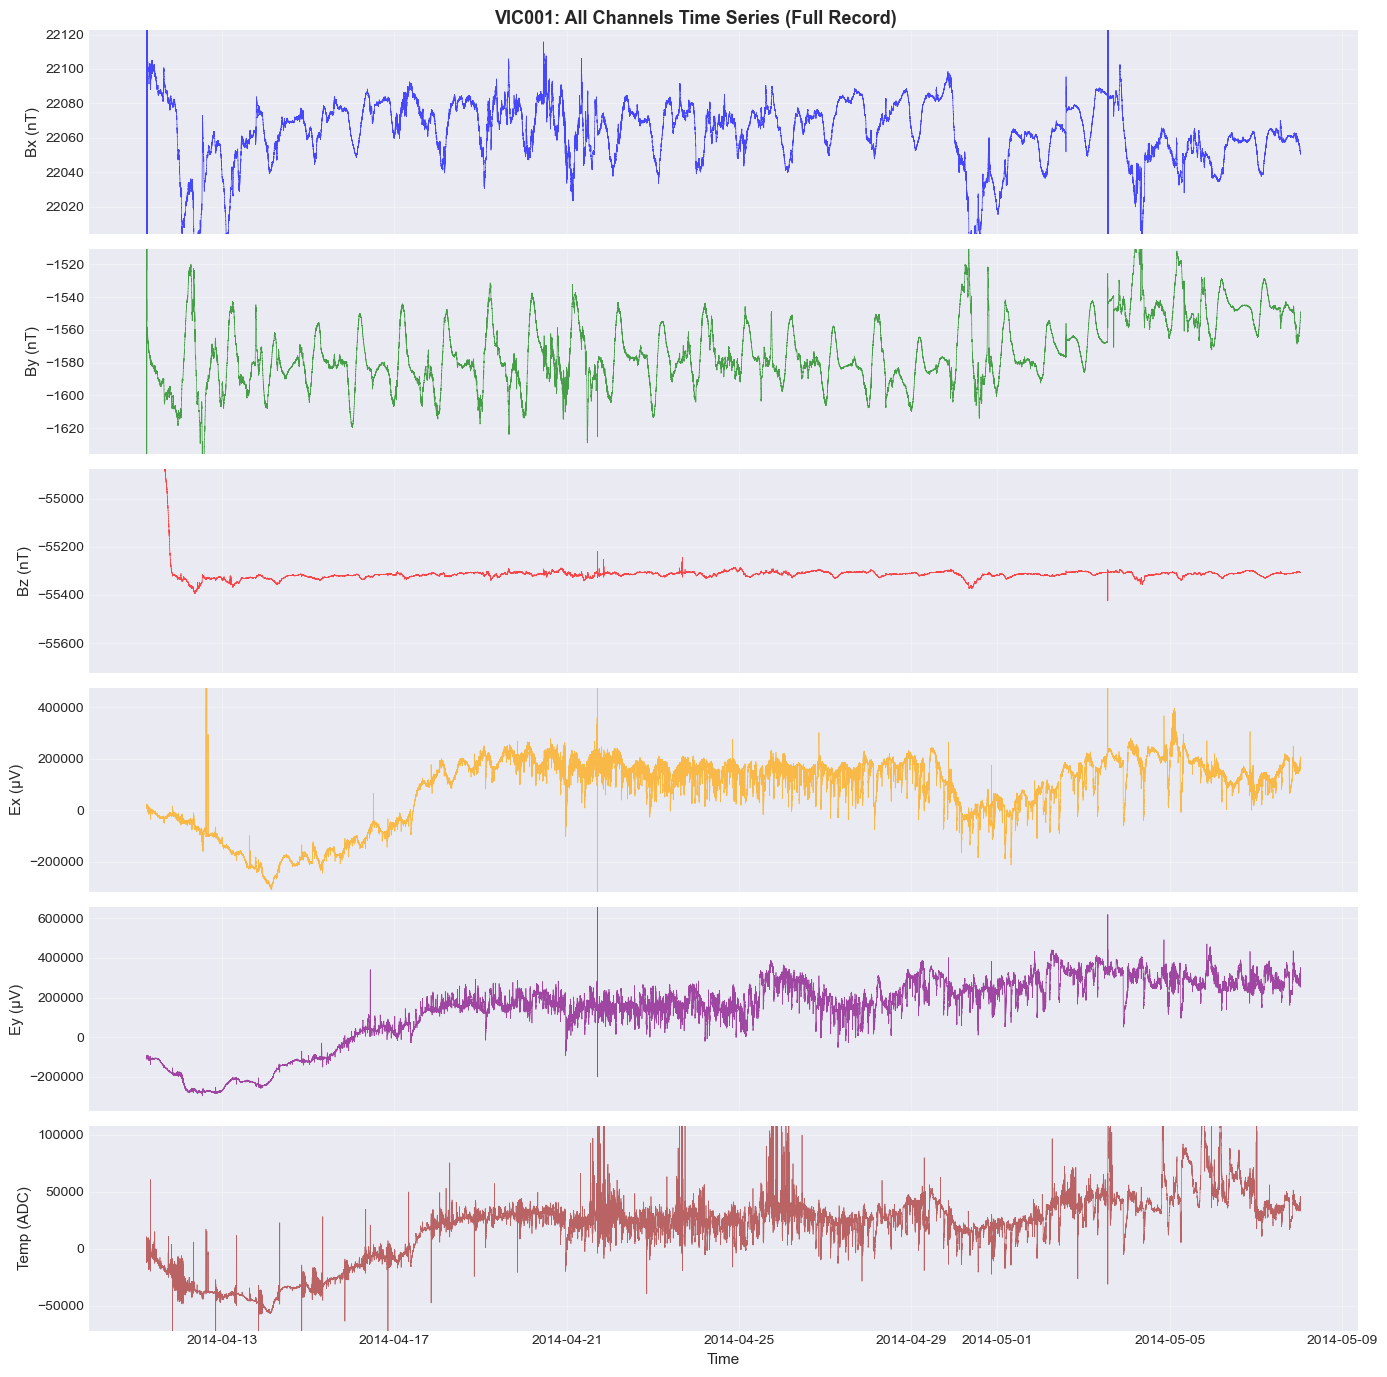

*Figure 3. Full time series of all 6 channels for VIC001 (26 days). Y-axis limits set to mean ± 3σ to handle occasional spikes while preserving detail. Magnetic channels (BX, BY, BZ) show diurnal variations and geomagnetic storms. Electric channels (EX, EY) show telluric currents. Temperature sensor (TP) shows seasonal drift.*

In [16]:
# Calculate ylim for each channel (mean ± 3σ)
def get_ylim(data, n_sigma=3):
    """Calculate y-axis limits as mean ± n_sigma * std."""
    mean = data.mean()
    std = data.std()
    return (mean - n_sigma*std, mean + n_sigma*std)

# Full record plot
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# Bx
axes[0].plot(df.index, df['BX'], 'b-', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('Bx (nT)', fontsize=11)
axes[0].set_ylim(get_ylim(df['BX']))
axes[0].grid(True, alpha=0.3)

# By
axes[1].plot(df.index, df['BY'], 'g-', linewidth=0.5, alpha=0.7)
axes[1].set_ylabel('By (nT)', fontsize=11)
axes[1].set_ylim(get_ylim(df['BY']))
axes[1].grid(True, alpha=0.3)

# Bz
axes[2].plot(df.index, df['BZ'], 'r-', linewidth=0.5, alpha=0.7)
axes[2].set_ylabel('Bz (nT)', fontsize=11)
axes[2].set_ylim(get_ylim(df['BZ']))
axes[2].grid(True, alpha=0.3)

# Ex
axes[3].plot(df.index, df['EX'], 'orange', linewidth=0.5, alpha=0.7)
axes[3].set_ylabel('Ex (µV)', fontsize=11)
axes[3].set_ylim(get_ylim(df['EX']))
axes[3].grid(True, alpha=0.3)

# Ey
axes[4].plot(df.index, df['EY'], 'purple', linewidth=0.5, alpha=0.7)
axes[4].set_ylabel('Ey (µV)', fontsize=11)
axes[4].set_ylim(get_ylim(df['EY']))
axes[4].grid(True, alpha=0.3)

# Temperature
axes[5].plot(df.index, df['TP'], 'brown', linewidth=0.5, alpha=0.7)
axes[5].set_ylabel('Temp (ADC)', fontsize=11)
axes[5].set_ylim(get_ylim(df['TP']))
axes[5].set_xlabel('Time', fontsize=11)
axes[5].grid(True, alpha=0.3)

plt.suptitle(f'{data_dir.name}: All Channels Time Series (Full Record)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

caption(f"Figure 3. Full time series of all 6 channels for {data_dir.name} ({(df.index[-1] - df.index[0]).days} days). "
        f"Y-axis limits set to mean ± 3σ to handle occasional spikes while preserving detail. "
        f"Magnetic channels (BX, BY, BZ) show diurnal variations and geomagnetic storms. "
        f"Electric channels (EX, EY) show telluric currents. "
        f"Temperature sensor (TP) shows seasonal drift.")

### 24-Hour Sample

In [17]:
# Select first 24 hours
start_time = df.index[0]
end_time = start_time + pd.Timedelta(days=1)
df_day = df[(df.index >= start_time) & (df.index < end_time)]

print(f"24-hour window: {df_day.index[0]} to {df_day.index[-1]}")
print(f"Samples: {len(df_day):,}")

24-hour window: 2014-04-11 06:00:00 to 2014-04-12 05:59:59.900000
Samples: 864,000


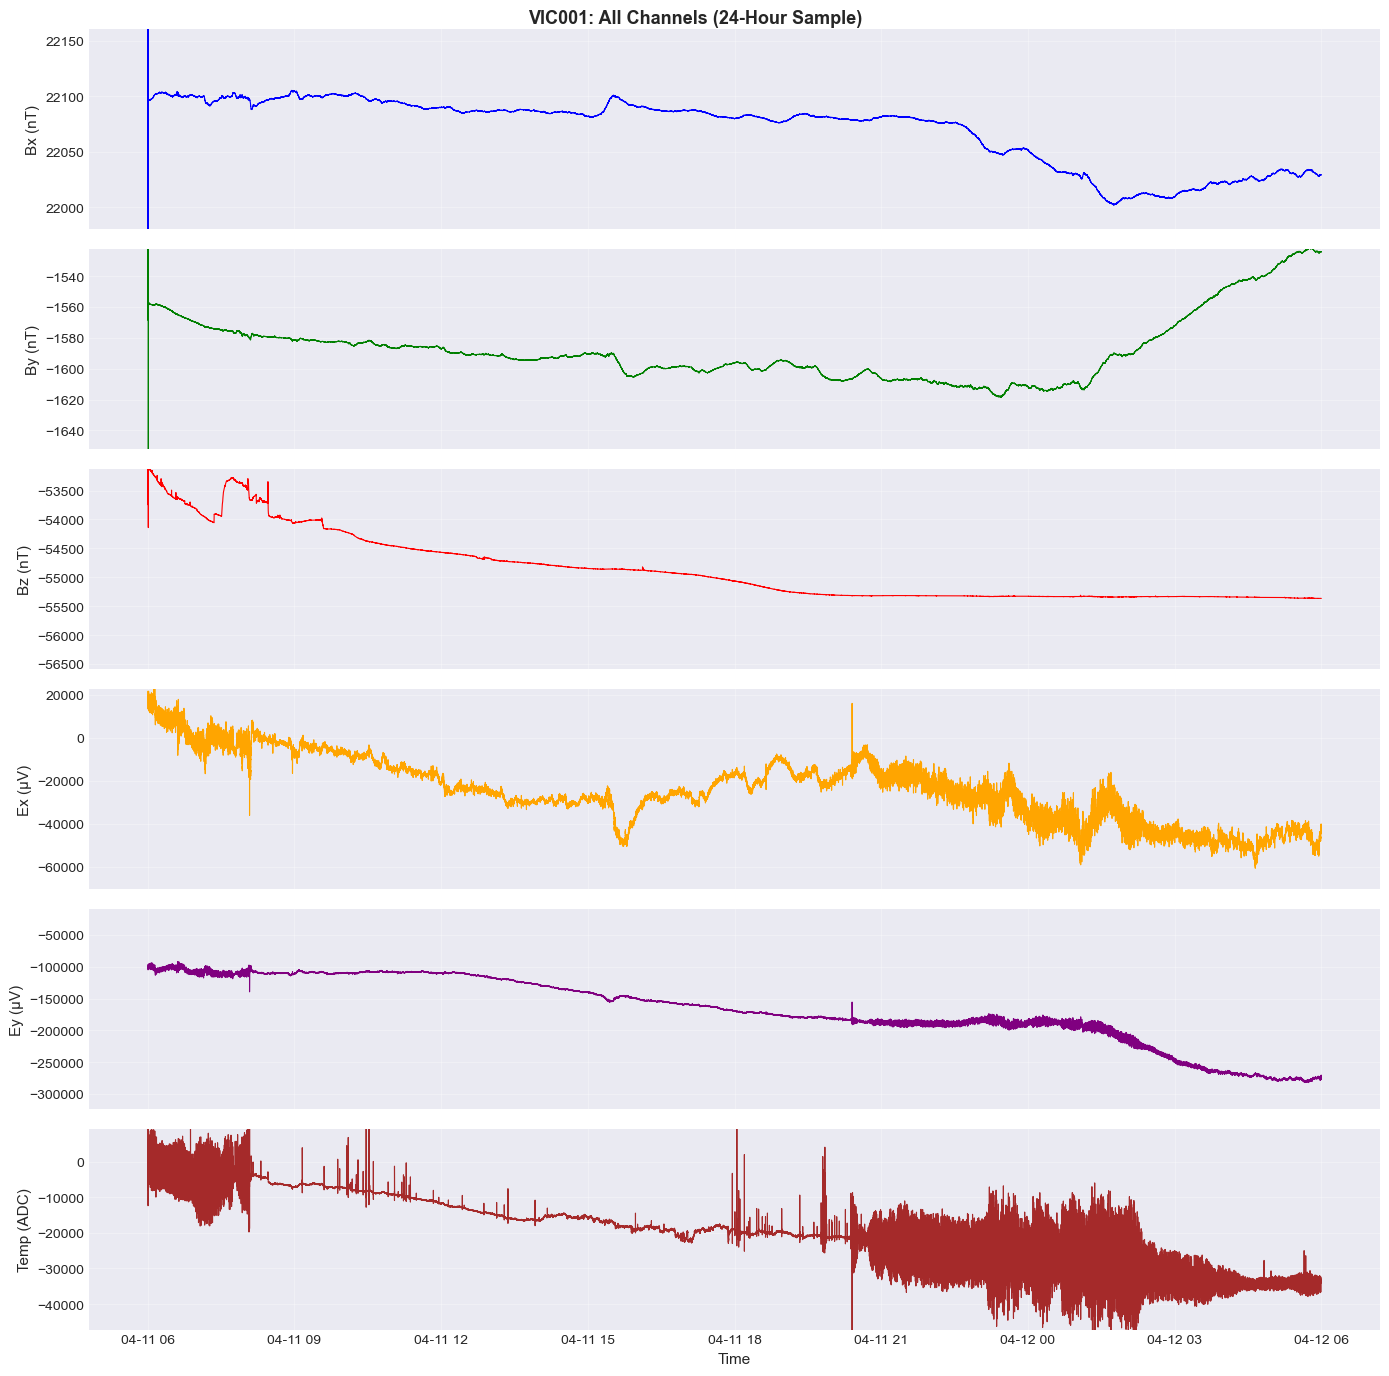

*Figure 4. 24-hour sample showing diurnal variations in all channels. Y-axis limits: mean ± 3σ. Diurnal pattern visible in magnetic components driven by ionospheric currents. Electric field variations correspond to magnetic variations via Maxwell's equations.*

In [18]:
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

# Bx
axes[0].plot(df_day.index, df_day['BX'], 'b-', linewidth=0.8)
axes[0].set_ylabel('Bx (nT)', fontsize=11)
axes[0].set_ylim(get_ylim(df_day['BX']))
axes[0].grid(True, alpha=0.3)

# By
axes[1].plot(df_day.index, df_day['BY'], 'g-', linewidth=0.8)
axes[1].set_ylabel('By (nT)', fontsize=11)
axes[1].set_ylim(get_ylim(df_day['BY']))
axes[1].grid(True, alpha=0.3)

# Bz
axes[2].plot(df_day.index, df_day['BZ'], 'r-', linewidth=0.8)
axes[2].set_ylabel('Bz (nT)', fontsize=11)
axes[2].set_ylim(get_ylim(df_day['BZ']))
axes[2].grid(True, alpha=0.3)

# Ex
axes[3].plot(df_day.index, df_day['EX'], 'orange', linewidth=0.8)
axes[3].set_ylabel('Ex (µV)', fontsize=11)
axes[3].set_ylim(get_ylim(df_day['EX']))
axes[3].grid(True, alpha=0.3)

# Ey
axes[4].plot(df_day.index, df_day['EY'], 'purple', linewidth=0.8)
axes[4].set_ylabel('Ey (µV)', fontsize=11)
axes[4].set_ylim(get_ylim(df_day['EY']))
axes[4].grid(True, alpha=0.3)

# Temperature
axes[5].plot(df_day.index, df_day['TP'], 'brown', linewidth=0.8)
axes[5].set_ylabel('Temp (ADC)', fontsize=11)
axes[5].set_ylim(get_ylim(df_day['TP']))
axes[5].set_xlabel('Time', fontsize=11)
axes[5].grid(True, alpha=0.3)

plt.suptitle(f'{data_dir.name}: All Channels (24-Hour Sample)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

caption("Figure 4. 24-hour sample showing diurnal variations in all channels. "
        "Y-axis limits: mean ± 3σ. "
        "Diurnal pattern visible in magnetic components driven by ionospheric currents. "
        "Electric field variations correspond to magnetic variations via Maxwell's equations.")

## 4. Data Quality Checks

In [19]:
# Calculate standard deviations for each channel
print("Outlier Analysis (>5σ):\n")
for col in ['BX', 'BY', 'BZ', 'EX', 'EY', 'TP']:
    mean = df[col].mean()
    std = df[col].std()
    
    # Count values beyond 5σ
    outliers = np.abs(df[col] - mean) > 5 * std
    n_outliers = outliers.sum()
    pct_outliers = 100 * n_outliers / len(df)
    
    print(f"{col:3s}: {n_outliers:8d} outliers (>5σ) = {pct_outliers:.4f}%")

Outlier Analysis (>5σ):

BX :       95 outliers (>5σ) = 0.0004%
BY :       89 outliers (>5σ) = 0.0004%
BZ :   225166 outliers (>5σ) = 0.9727%
EX :        1 outliers (>5σ) = 0.0000%
EY :        0 outliers (>5σ) = 0.0000%
TP :    14488 outliers (>5σ) = 0.0626%


In [20]:
# Check for data gaps
dt = df.index.to_series().diff()
expected_dt = pd.Timedelta(seconds=0.1)
gaps = dt[dt > 1.5 * expected_dt]

print(f"Data Gap Analysis:\n")
print(f"Number of gaps detected: {len(gaps)}")
if len(gaps) > 0:
    print("\nLargest gaps:")
    display(gaps.nlargest(10))
else:
    print("No significant gaps detected - continuous recording!")

Data Gap Analysis:

Number of gaps detected: 0
No significant gaps detected - continuous recording!


## 5. Summary

### Statistical Review Results

- **Loaded statistics from all Victorian AusLAMP sites**
- **Combined with GPS metadata** (lat/lon/elevation)
- **Identified sites with potential issues** based on:
  - Mean field anomalies (>1000 nT from regional median)
  - Excessive outliers (>1% of samples)
  - High noise (std > 50 nT)
- **Saved complete dataset** to CSV for further analysis

### Data Exported

**File**: `outputs/victorian_sites_qaqc.csv`

**Contents**:
- Station metadata (ID, GPS coordinates, recording dates)
- Field statistics (mean, std for all components)
- Quality flags (anomalies, outliers, high noise)

### Single Site Analysis (VIC001)

- All 6 channels loaded successfully
- Data quality: minimal outliers (<1%), continuous recording
- Time series plots use mean ± 3σ limits to handle spikes
- Diurnal variations clearly visible

### Next Steps

1. Investigate flagged sites in detail
2. Calculate power spectral densities
3. Identify geomagnetic events (storms, substorms)
4. Proceed to MT processing workflow